In [1]:
import torch
import torch.nn as nn
import h5py
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import trange, tqdm
from sklearn.metrics import precision_score
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import math
from torch.nn import CrossEntropyLoss

In [2]:
finetune_path = "/home/pvg/finetune_subset.h5"

In [3]:
with h5py.File(finetune_path, "r") as f:
    # only first 100 batches are loading
    images = f["jet"][:] # jet
    labels = f["Y"][:] # labels

In [4]:
class JetDataset(Dataset):

    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [6]:
train_dataset = JetDataset(X_train, y_train)
val_dataset = JetDataset(X_val, y_val)
test_dataset = JetDataset(X_test, y_test)

In [7]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [8]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 125, 125, 8])
torch.Size([32, 1])


In [9]:
class patchEmbedding(nn.Module):
  def __init__(self,patch_size,in_channels,embed_dim):
    super().__init__()
    self.proj = nn.Conv2d(
        in_channels = in_channels,
        out_channels = embed_dim,
        stride = patch_size,
        kernel_size = patch_size
    )
  def forward(self,x):
    
    ## assuming the shape of x = (batch size,channels,height,width)
    x = self.proj(x) # (batch_size,768,14,14)
    #print("proj",x.shape)
    x = x.flatten(2,-1) # (batch,768,196)
    #print("flatten",x.shape)
    x = x.transpose(1,2) # (batch_size,196,768)
    #print("transpose",x.shape)
    return x

In [12]:
patch = patchEmbedding(5,8,200)

In [13]:
patch(images).shape 

RuntimeError: Given groups=1, weight of size [200, 8, 5, 5], expected input[32, 125, 125, 8] to have 8 channels, but got 125 channels instead

In [40]:
class PositionalEncoding(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    ## img = (3,224,224) => (batch_size,patches,embed_dim)
    self.d_k = embed_dim
    self.patches = patches + 1
    pe = torch.zeros(self.patches,self.d_k) # (197,768)
    div = torch.exp(torch.arange(0,self.d_k,2).float() * -(math.log(1000.0)/self.d_k)) # (1,384)
    ### range(0,df-2,2) => 2i
    ### -(math.log(1000.0)/self.d_k) => -log(1000.0)/d_k
    ### multiplication => (2i/d_k) * -log(100.000)
    ### exp = -1000.0^(2i/d_k) => 1/1000.o^(2i/dk)
    position = torch.arange(0,self.patches).float().unsqueeze(1) # (197,1)
    #print("before position")
    pe[:,0::2] = torch.sin(position*div) # only even positions are taken (197,1)*(1,384) = (197,384)
    pe[:,1::2] = torch.cos(position*div) # only the odd positions are taken(197,384)
    # (batch,197,384)
    #print("pe done ")
    pe = pe.unsqueeze(0) # adding the batch parameter
    self.register_buffer("pe",pe) # setting in the buffer to avoid the backtracking
  def forward(self,x):
    return x + (self.pe[:,:x.size(1),:]).requires_grad_(False) # adding the positional vector => :self.patches are added to avoid the upscale in that dim

In [41]:
class MultiHeadAttention(nn.Module):
  def __init__(self,seq_len,embedding_dim,heads,head_dim,num_chunks,chunk_size):
    super().__init__()
    #assert seq_len == math.floor(seq_len / chunk_size) *chunk_size
    assert embedding_dim == heads * head_dim
    self.heads = heads
    self.head_dim = head_dim
    self.chunk_size = chunk_size
    self.num_chunks = math.ceil(seq_len / chunk_size)
    self.Q = nn.Linear(embedding_dim,embedding_dim)
    self.K = nn.Linear(embedding_dim,embedding_dim)
    self.V = nn.Linear(embedding_dim,embedding_dim)

  def feature_map(self,x):
    return torch.clamp(F.elu(x) + 1,min=0.0,max=5.0)

  def forward(self,x):
    # x = (32,100,128)
    B,L,E =  x.shape
    #print(type(L))
    q = self.feature_map(self.Q(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2) # (32,100,128) => (32,100,2,64) => (32,2,100,64)
    k = self.feature_map(self.K(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    v = self.feature_map(self.V(x)).view(B,L, self.heads, self.head_dim).transpose(1, 2)
    # 2. Compute Global KV State (The associative trick)
    # Instead of chunks, we aggregate the entire image context at once.
    # kv shape: (B, heads, head_dim, head_dim)
    kv = torch.matmul(k.transpose(-1, -2), v)

    # 3. Compute Normalization factor (Denominator)
    # z shape: (B, heads, head_dim, 1)
    z = k.sum(dim=2, keepdim=True).transpose(-1, -2)

    # 4. Global Attention Output
    # num: (B, heads, L, head_dim)
    num = torch.matmul(q, kv)
    # den: (B, heads, L, 1)
    den = torch.matmul(q, z) + 1e-5
    out = num / den
    out = out.transpose(1, 2).reshape(B, L, E)
    return out

In [42]:
class LayerNorm(nn.Module):
  def __init__(self):
    super().__init__()
    self.eps = 0.01
    self.alpha = nn.Parameter(torch.ones(1))
    self.beta = nn.Parameter(torch.ones(1))
    pass
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    std = x.std(dim=-1,keepdim=True)
    return (self.alpha * ((x - mean)/(std+self.eps))) + self.beta

In [43]:
class FeedForwardlayer(nn.Module):
  def __init__(self,patches,embed_dim):
    super().__init__()
    self.dim = 348
    self.fc_1 = nn.Linear(embed_dim,self.dim)
    self.fc_2 = nn.Linear(self.dim,embed_dim)
    self.relu = nn.ReLU()
  def forward(self,x):
    return self.fc_2(self.relu(self.fc_1(x)))

In [44]:
class ResidualBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm = LayerNorm()
  def forward(self,X,sublayer):
    #print("in residual ")
    return X + sublayer(self.layer_norm(X)) # ada and norm
    ## here the sublayer is normed first then add

In [45]:
class EncoderBlock(nn.Module):
  def __init__(self,attention:MultiHeadAttention,fnn:FeedForwardlayer,patches,embed_dim):
    super().__init__()
    self.attention = attention
    self.fnn = fnn
    self.patches = patches
    self.embed_dim = embed_dim
    self.residual = nn.ModuleList([ResidualBlock() for _ in range(2)]) # we want and 2 residual layer connected
  def forward(self,X):
    X = self.residual[0](X,lambda x:self.attention(X)) ## here the attention is second layer (sublayer) and the X is the input which is going to add
    X = self.residual[1](X,lambda x:self.fnn(X))
    return X

In [46]:
class ViTClassifier(nn.Module):
    def __init__(self,embeded_dim,num_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(embeded_dim, 2048),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        return self.head(x)

In [47]:
class ViT(nn.Module):
    def __init__(self, patches=197,patch_size=16, embed_dim=768, num_classes=10):
        super().__init__()
        self.patch_embedding = patchEmbedding(patch_size, 8, embed_dim)
        self.positional = PositionalEncoding(patches, embed_dim)
        self.encoder = encoder
        self.classifier = classifier
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

    def forward(self, x):
        x = x.permute(0,3,1,2)
        x = self.patch_embedding(x)
        #print(x.shape)
        #print("cls",cls_token.shape)
        #print(x.shape)
        x = torch.cat([self.cls_token.expand(x.size(0), -1, -1), x], dim=1)
        #print(x.shape)
        x = self.positional(x)
        x = self.encoder(x)
        cls_features = x[:, 0, :]  # Take CLS token
        return self.classifier(cls_features)


In [48]:
patches = 625
embed_dim =  200
num_classes = 2
patch_size = 5
heads = 5
in_channels = 8
head_dim = 40
num_chunks = 5
chunk_size = 5
patch_embedding = patchEmbedding(patch_size,in_channels,embed_dim)
positional = PositionalEncoding(patches,embed_dim)
attention = MultiHeadAttention(patches,embed_dim,heads,head_dim,num_chunks,chunk_size)
residual = ResidualBlock()
fnn = FeedForwardlayer(patches,embed_dim)
encoder = EncoderBlock(attention,fnn,patches,embed_dim)
classifier = ViTClassifier(embed_dim,num_classes)

In [49]:
model = ViT(patches,patch_size,embed_dim,num_classes)

In [50]:
model

ViT(
  (patch_embedding): patchEmbedding(
    (proj): Conv2d(8, 200, kernel_size=(5, 5), stride=(5, 5))
  )
  (positional): PositionalEncoding()
  (encoder): EncoderBlock(
    (attention): MultiHeadAttention(
      (Q): Linear(in_features=200, out_features=200, bias=True)
      (K): Linear(in_features=200, out_features=200, bias=True)
      (V): Linear(in_features=200, out_features=200, bias=True)
    )
    (fnn): FeedForwardlayer(
      (fc_1): Linear(in_features=200, out_features=348, bias=True)
      (fc_2): Linear(in_features=348, out_features=200, bias=True)
      (relu): ReLU()
    )
    (residual): ModuleList(
      (0-1): 2 x ResidualBlock(
        (layer_norm): LayerNorm()
      )
    )
  )
  (classifier): ViTClassifier(
    (head): Sequential(
      (0): Linear(in_features=200, out_features=2048, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=2048, out_features=2, bias=True)
    )
  )
)

In [54]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ViT(patches, patch_size, embed_dim, num_classes=2).to(device)  # 2 classes!
epochs = 10
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)  # Better optimizer
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Storage lists
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_precs, val_precs = [], []
best_val_acc = 0
for epoch in trange(epochs, desc="Training Progress"):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for batch_idx, (image, label) in enumerate(tqdm(train_loader, desc=f"Train {epoch}", leave=False)):
        image, label = image.to(device), label.to(device)
        label = label.squeeze(1).long()
        optimizer.zero_grad()
        pred = model(image)  # [batch, 2]
        loss = criterion(pred, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(pred, 1)
        total += label.size(0)
        correct += (predicted == label).sum().item()

        # Precision collection
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    # Epoch metrics
    train_loss = total_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_precs.append(train_prec)
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for image, label in tqdm(val_loader, desc=f"Val {epoch}", leave=False):
            image, label = image.to(device), label.to(device)
            label = label.squeeze(1).long()
            pred = model(image)
            loss = criterion(pred, label)
            val_loss += loss.item()

            _, predicted = torch.max(pred, 1)
            val_total += label.size(0)
            val_correct += (predicted == label).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(label.cpu().numpy())

    val_loss_avg = val_loss / len(val_loader)
    val_acc = 100. * val_correct / val_total
    val_prec = precision_score(val_labels, val_preds, average='binary', zero_division=0)

    val_losses.append(val_loss_avg)
    val_accs.append(val_acc)
    val_precs.append(val_prec)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict":scheduler.state_dict(),
            "loss": loss
        }, "checkpoint.pth")

    scheduler.step()
    print(f"Epoch {epoch+1:02d}/{epochs}")
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%, Prec={train_prec:.3f}")
    print(f"  Val:   Loss={val_loss_avg:.4f}, Acc={val_acc:.2f}%, Prec={val_prec:.3f} | Best: {best_val_acc:.2f}%")
    print(f"  LR: {scheduler.get_last_lr()[0]:.2e}")
    print("-" * 60)


Train 0: 100%|███████████████████████████████▊| 218/219 [00:13<00:00, 15.73it/s]
                                                                                
Training Progress:  10%|██▌                      | 1/10 [00:15<02:17, 15.29s/it]

Epoch 01/10
  Train: Loss=0.5784, Acc=69.83%, Prec=0.685
  Val:   Loss=0.5058, Acc=75.33%, Prec=0.699 | Best: 75.33%
  LR: 2.93e-04
------------------------------------------------------------



Train 1: 100%|███████████████████████████████▊| 218/219 [00:13<00:00, 16.19it/s]
                                                                                
Training Progress:  20%|█████                    | 2/10 [00:30<01:59, 14.96s/it]

Epoch 02/10
  Train: Loss=0.5010, Acc=76.89%, Prec=0.741
  Val:   Loss=0.5004, Acc=75.60%, Prec=0.691 | Best: 75.60%
  LR: 2.71e-04
------------------------------------------------------------



Train 2: 100%|███████████████████████████████▊| 218/219 [00:13<00:00, 16.67it/s]
                                                                                
Training Progress:  30%|███████▌                 | 3/10 [00:44<01:44, 14.88s/it]

...

Epoch 08/10
  Train: Loss=0.4394, Acc=79.96%, Prec=0.763
  Val:   Loss=0.4668, Acc=78.53%, Prec=0.742 | Best: 78.53%
  LR: 2.86e-05
------------------------------------------------------------



Train 8: 100%|███████████████████████████████▊| 218/219 [00:13<00:00, 16.33it/s]
                                                                                
Training Progress:  90%|██████████████████████▌  | 9/10 [02:14<00:14, 14.94s/it]

Epoch 09/10
  Train: Loss=0.4347, Acc=80.24%, Prec=0.766
  Val:   Loss=0.4721, Acc=76.07%, Prec=0.701 | Best: 78.53%
  LR: 7.34e-06
------------------------------------------------------------



Train 9: 100%|███████████████████████████████▊| 218/219 [00:13<00:00, 16.52it/s]
                                                                                
Training Progress: 100%|████████████████████████| 10/10 [02:28<00:00, 14.90s/it]

Epoch 10/10
  Train: Loss=0.4307, Acc=80.54%, Prec=0.766
  Val:   Loss=0.4686, Acc=78.20%, Prec=0.734 | Best: 78.53%
  LR: 0.00e+00
------------------------------------------------------------


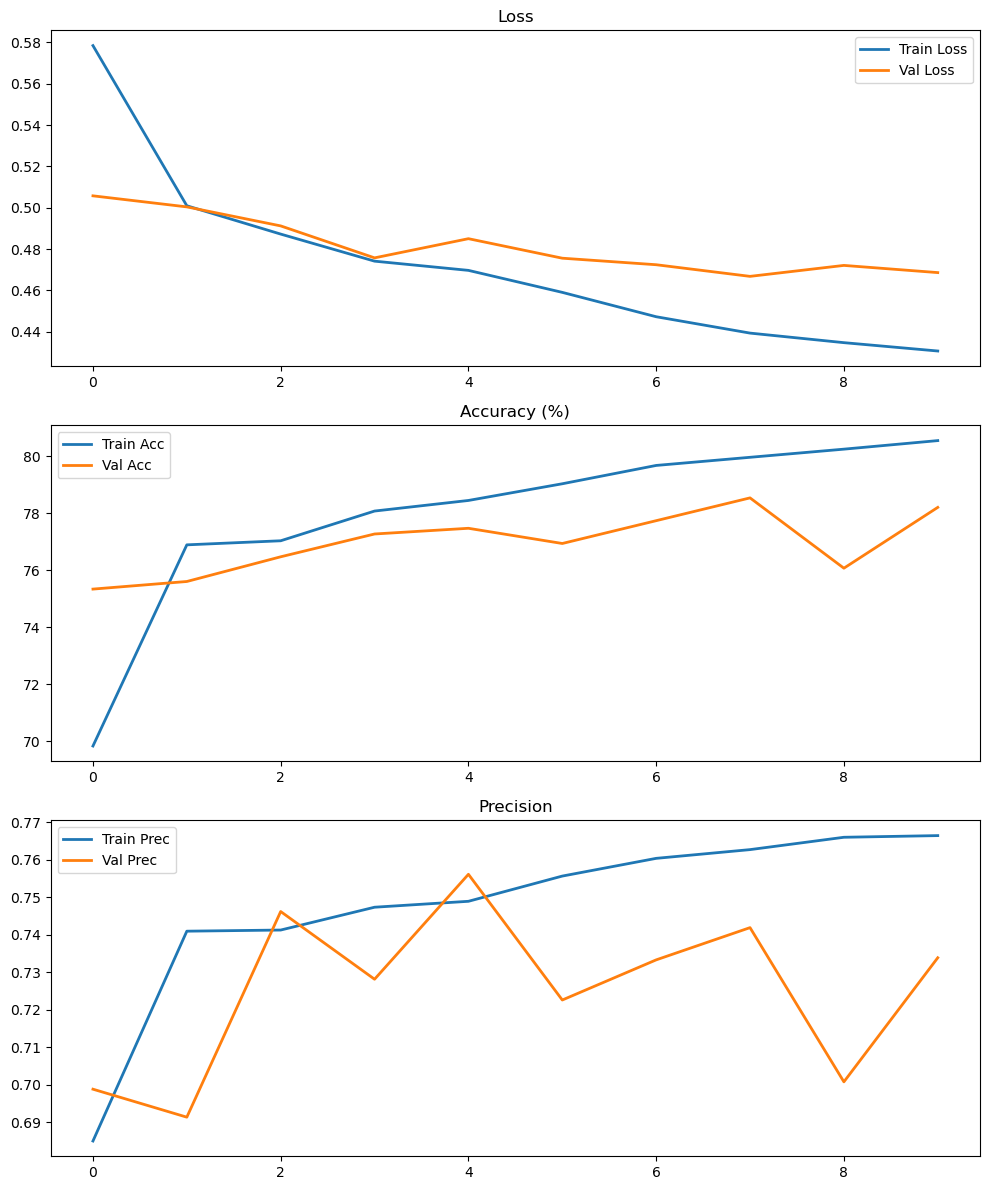


🎉 Final Best Val Acc: 78.53%
✅ Best model saved: best_vit_jet_model.pth


In [55]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Val Loss', linewidth=2)
ax1.set_title('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Acc', linewidth=2)
ax2.plot(val_accs, label='Val Acc', linewidth=2)
ax2.set_title('Accuracy (%)')
ax2.legend()

ax3.plot(train_precs, label='Train Prec', linewidth=2)
ax3.plot(val_precs, label='Val Prec', linewidth=2)
ax3.set_title('Precision')
ax3.legend()

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🎉 Final Best Val Acc: {best_val_acc:.2f}%")
print(f"✅ Best model saved: best_vit_jet_model.pth")
